In [2]:
import pandas as pd

import seaborn as sb
import matplotlib.pyplot as plt

dtypes
head()
.tail()
.index()
.columns()
.describe()
.sort_index()
.sort_values()
.at()
.iat()
.loc()
.iloc()


In [3]:
DATA_PATH = "../Data/Raw data"


In [4]:
CUSTOMERS_PATH = "olist_customers_dataset.csv"
GEOLOCATION_PATH = "olist_geolocation_dataset.csv"
ORDERS_PATH = "olist_orders_dataset.csv"
ORDER_ITEMS_PATH = "olist_order_items_dataset.csv"
ORDER_PAYMENTS_PATH = "olist_order_payments_dataset.csv"
ORDER_REVIEWS_PATH = "olist_order_reviews_dataset.csv"
PRODUCTS_PATH = "olist_products_dataset.csv"
SELLERS_PATH = "olist_sellers_dataset.csv"
PRODUCT_TRANSLATIONS_PATH = "product_category_name_translation.csv"

In [5]:
customers_df = pd.read_csv(DATA_PATH + "/" + CUSTOMERS_PATH) 
geolocation_df = pd.read_csv(DATA_PATH + "/" + GEOLOCATION_PATH) 
orders_df = pd.read_csv(DATA_PATH + "/" + ORDERS_PATH) 
order_items_df = pd.read_csv(DATA_PATH + "/" + ORDER_ITEMS_PATH) 
order_payments_df = pd.read_csv(DATA_PATH + "/" + ORDER_PAYMENTS_PATH) 
order_reviews_df = pd.read_csv(DATA_PATH + "/" + ORDER_REVIEWS_PATH) 
products_df = pd.read_csv(DATA_PATH + "/" + PRODUCTS_PATH) 
sellers_df = pd.read_csv(DATA_PATH + "/" + SELLERS_PATH) 
product_translations_df = pd.read_csv(DATA_PATH + "/" + PRODUCT_TRANSLATIONS_PATH) 

In [6]:
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [7]:
customer_id_values = customers_df["customer_unique_id"].value_counts()

customer_id_values[customer_id_values > 1]

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
574e36a816bf7a295404e686062fc0de     2
76f7d40948174f5cde0fcf8e6147b59d     2
88fcb680dc8cd2e540010c0750b78242     2
2dcbfb99d95c7ba6eb992a98627f45b8     2
da29b8a3970adddb9ed2dc8a492065af     2
Name: count, Length: 2997, dtype: int64

In [8]:
# Merge the customers data frame and geolocation dataframe

customer_x_orders = pd.merge(left = customers_df, right = orders_df, how = "inner", left_on = "customer_id", right_on = "customer_id")

# Get the columns lists 

customer_x_orders


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00


In [9]:
# Merge customer_x_orders with order_items_df

customer_and_orders_x_items = pd.merge(left = customer_x_orders, right = order_items_df, how = "left", on = "order_id")

customer_and_orders_x_items

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88
113421,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16
113422,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04
113423,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-09 21:15:51,689.00,22.07


In [10]:
# Merge customer_and_orders_x_items(caoi) with order payments

caoi_x_payment = pd.merge(left = customer_and_orders_x_items, right = order_payments_df, how = "left", on = "order_id")

caoi_x_payment

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,1.0,credit_card,2.0,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,1.0,credit_card,8.0,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,1.0,credit_card,7.0,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,1.0,credit_card,1.0,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,1.0,credit_card,8.0,252.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118429,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88,1.0,credit_card,6.0,88.78
118430,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16,1.0,credit_card,3.0,129.06
118431,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04,1.0,credit_card,5.0,56.04
118432,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-09 21:15:51,689.00,22.07,1.0,credit_card,2.0,711.07


In [11]:
# Merge between caoi_x_payment(caoi_payments) and order reviews

caoi_payment_reviews = pd.merge(left = caoi_x_payment, right = order_reviews_df, how = "left", on = "order_id")

caoi_payment_reviews

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,1.0,credit_card,6.0,88.78,36e2cdbaa9f639b57c53b37ac798fee8,4.0,Recomendo,NaN,2018-04-14 00:00:00,2018-04-28 11:15:04
119139,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,1.0,credit_card,3.0,129.06,b273b431c3aedb4eed18643309652940,5.0,NaN,NaN,2018-04-12 00:00:00,2018-04-16 10:36:05
119140,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,1.0,credit_card,5.0,56.04,fa4f16891e6b2edd1354668d07f5648b,1.0,Chateada,Esperava qualidade no atendimento e estou tend...,2018-05-04 00:00:00,2018-05-08 01:41:07
119141,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,1.0,credit_card,2.0,711.07,0bcdc9e450ea500811a8d39ee993cd47,5.0,NaN,NaN,2017-11-17 00:00:00,2017-11-19 23:34:18


In [12]:
# Merge between caoi_payment_reviews(caoipr) and products_df 

caoipr_x_products = pd.merge(left = caoi_payment_reviews, right = products_df, how = "left", on = "product_id")

caoipr_x_products

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,review_creation_date,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,2017-05-26 00:00:00,2017-05-30 22:34:40,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,2018-01-30 00:00:00,2018-02-10 22:43:29,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,2018-06-15 00:00:00,2018-06-15 12:10:59,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,2018-03-29 00:00:00,2018-04-02 18:36:47,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,2018-08-10 00:00:00,2018-08-17 01:59:52,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,2018-04-14 00:00:00,2018-04-28 11:15:04,livros_interesse_geral,51.0,489.0,2.0,611.0,22.0,22.0,23.0
119139,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,2018-04-12 00:00:00,2018-04-16 10:36:05,esporte_lazer,51.0,1193.0,1.0,1211.0,25.0,24.0,22.0
119140,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,2018-05-04 00:00:00,2018-05-08 01:41:07,beleza_saude,60.0,575.0,1.0,870.0,25.0,20.0,18.0
119141,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,2017-11-17 00:00:00,2017-11-19 23:34:18,relogios_presentes,59.0,452.0,1.0,710.0,19.0,13.0,14.0


In [13]:
# Merge caoipr_x_products and sellers_df

caoipr_products_seller = pd.merge(left = caoipr_x_products, right = sellers_df, how = "left", on = "seller_id")


caoipr_products_seller

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,8577.0,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,88303.0,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,8577.0,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,8577.0,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,14940.0,ibitinga,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,51.0,489.0,2.0,611.0,22.0,22.0,23.0,17400.0,garca,SP
119139,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,51.0,1193.0,1.0,1211.0,25.0,24.0,22.0,14802.0,araraquara,SP
119140,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,60.0,575.0,1.0,870.0,25.0,20.0,18.0,3304.0,sao paulo,SP
119141,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,59.0,452.0,1.0,710.0,19.0,13.0,14.0,14840.0,guariba,SP


In [14]:
# Merge caoipr_products_seller and product_category_name_translation 

# Finally, we get a single table, which will be called olist_df

olist_df = pd.merge(left = caoipr_products_seller, right = product_translations_df, how = "left", on = "product_category_name")

olist_df.nunique()

customer_id                      99441
customer_unique_id               96096
customer_zip_code_prefix         14994
customer_city                     4119
customer_state                      27
order_id                         99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
order_item_id                       21
product_id                       32951
seller_id                         3095
shipping_limit_date              93318
price                             5968
freight_value                     6999
payment_sequential                  29
payment_type                         5
payment_installments                24
payment_value                    29077
review_id                        98410
review_score                         5
review_comment_title              4527
review_comment_message   

In [59]:
olist_df["freight_value"].describe()

count    118310.000000
mean         20.032387
std          15.836850
min           0.000000
25%          13.080000
50%          16.280000
75%          21.180000
max         409.680000
Name: freight_value, dtype: float64

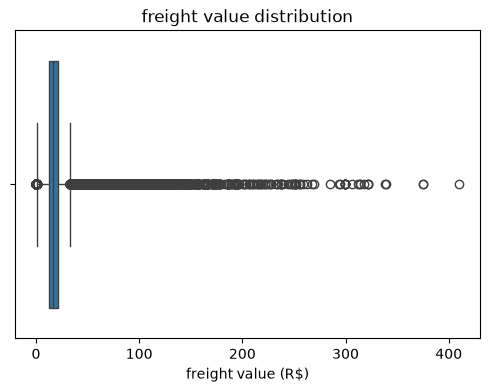

In [60]:
plt.figure(figsize=(6,4))

sb.boxplot(x = olist_df["freight_value"])

plt.title("freight value distribution")

plt.xlabel("freight value (R$)")

plt.show()

In [57]:
olist_df["price"].describe()

count    118310.000000
mean        120.646603
std         184.109691
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

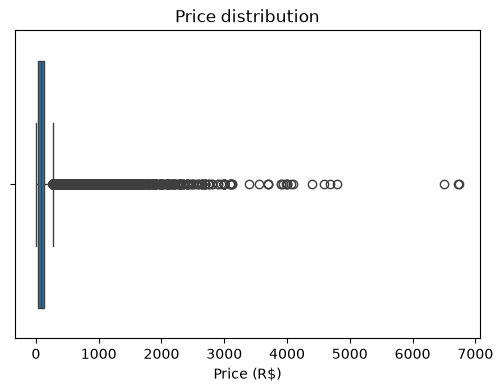

In [58]:
# Price column boxplot

plt.figure(figsize=(6,4))

sb.boxplot(x = olist_df["price"])

plt.title("Price distribution")

plt.xlabel("Price (R$)")

plt.show()

In [15]:
# olist_df columns overview

olist_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'product_category_name_english'],
      dtype='str')

max_date = olist_df["order_purchase_timestamp"].max()

min_date = olist_df["order_purchase_timestamp"].min()

difference_days = (olist_df["max_date"]- olist_df["min_date"]).dt.date()

difference_days

In [16]:
# you can delete this later

counts_unique_id = olist_df["customer_unique_id"].value_counts()

gratertwo = counts_unique_id[counts_unique_id>2]

gratertwo

customer_unique_id
9a736b248f67d166d2fbb006bcb877c3    75
6fbc7cdadbb522125f4b27ae9dee4060    38
f9ae226291893fda10af7965268fb7f6    35
8af7ac63b2efbcbd88e5b11505e8098a    29
569aa12b73b5f7edeaa6f2a01603e381    26
                                    ..
772c4d116b85873c6d1b797314b70c4c     3
a7941a8ddbfe8fde0bd23ae272484043     3
a5ba329297100ea689fa263768b35b8b     3
c6f8e1db66045b7e49203b47b5ce816f     3
4452b8ef472646c4cc042cb31a291f3b     3
Name: count, Length: 3941, dtype: int64

# Create the churn column(rewrite)

In [17]:
# Change the data type to date time

olist_df["order_purchase_timestamp"] = pd.to_datetime(olist_df["order_purchase_timestamp"])

In [18]:
# First, the olist dataframe will be ordered by order_purchase_timestamp

olist_df = olist_df.sort_values(by = ["customer_unique_id","order_purchase_timestamp"])

In [19]:
olist_df['purchase_date'] = olist_df['order_purchase_timestamp'].dt.date

In [20]:
clean_purchases = (olist_df.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])
                            .drop_duplicates(subset=['customer_unique_id', 'purchase_date']))

clean_purchases

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,purchase_date
76714,fadbb3709178fc513abc1b2670aa1ad2,0000366f3b9a7992bf8c76cfdf3221e2,7787,cajamar,SP,e22acc9c116caa3f2b7121bbb380d08e,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,...,1.0,1500.0,34.0,7.0,32.0,13405.0,piracicaba,SP,bed_bath_table,2018-05-10
29466,4cb282e167ae9234755102258dd52ee8,0000b849f77a49e4a4ce2b2a4ca5be3f,6053,osasco,SP,3594e05a005ac4d06a72673270ef9ec9,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,...,1.0,375.0,26.0,11.0,18.0,2215.0,sao paulo,SP,health_beauty,2018-05-07
48987,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,b33ec3b699337181488304f362a6b734,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,...,3.0,1500.0,25.0,50.0,35.0,13232.0,campo limpo paulista,SP,stationery,2017-03-10
68397,914991f0c02ef0843c0e7010c819d642,0000f6ccb0745a6a4b88665a16c9f078,66812,belem,PA,41272756ecddd9a9ed0180413cc22fb6,delivered,2017-10-12 20:29:41,2017-10-12 20:49:17,2017-10-13 20:08:19,...,5.0,150.0,19.0,5.0,11.0,3569.0,sao paulo,SP,telephony,2017-10-12
97337,47227568b10f5f58a524a75507e6992c,0004aac84e0df4da2b147fca70cf8255,18040,sorocaba,SP,d957021f1127559cd947b62533f484f7,delivered,2017-11-14 19:45:42,2017-11-14 20:06:52,2017-11-16 19:52:10,...,3.0,6050.0,16.0,3.0,11.0,12327.0,jacarei,SP,telephony,2017-11-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106897,74be082247cd677a147d83ee670e9d53,fffcf5a5ff07b0908bd4e2dbc735a684,55250,sanharo,PE,725cf8e9c24e679a8a5a32cb92c9ce1e,delivered,2017-06-08 21:00:36,2017-06-08 21:15:16,2017-06-23 13:03:27,...,1.0,30000.0,55.0,75.0,61.0,3908.0,sao paulo,SP,health_beauty,2017-06-08
11771,0ecf8e0a08148af0bf313184f167670a,fffea47cd6d3cc0a88bd621562a9d061,44054,feira de santana,BA,c71b9252fd7b3b263aaa4cb09319a323,delivered,2017-12-10 20:07:56,2017-12-10 20:16:20,2017-12-21 16:27:01,...,2.0,1720.0,33.0,36.0,27.0,18500.0,laranjal paulista,SP,baby,2017-12-10
82683,27f584b0f1dc4e610065c240f68b6be0,ffff371b4d645b6ecea244b27531430a,78552,sinop,MT,fdc45e6c7555e6cb3cc0daca2557dbe1,delivered,2017-02-07 15:49:16,2017-02-07 16:02:44,2017-02-08 10:04:37,...,5.0,600.0,17.0,15.0,13.0,30550.0,belo horizonte,MG,auto,2017-02-07
113762,832a3b0254347d409512ae92eaf154a6,ffff5962728ec6157033ef9805bacc48,29460,bom jesus do norte,ES,94d3ee0bc2a0af9d4fa47a4d63616e8d,delivered,2018-05-02 15:17:41,2018-05-02 15:58:47,2018-05-03 16:45:00,...,3.0,444.0,20.0,14.0,16.0,14050.0,ribeirao preto,SP,watches_gifts,2018-05-02


In [21]:
# Make sure the data only includes until 2017-09-01

revision_date =  pd.to_datetime("2017-09-01")

clean_purchases_cut = clean_purchases[clean_purchases["order_purchase_timestamp"] < revision_date]

clean_purchases_cut

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,purchase_date
48987,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,b33ec3b699337181488304f362a6b734,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,...,3.0,1500.0,25.0,50.0,35.0,13232.0,campo limpo paulista,SP,stationery,2017-03-10
70344,3b37fb626fdf46cd99d37ec62afa88ff,0005e1862207bf6ccc02e4228effd9a0,25966,teresopolis,RJ,ae76bef74b97bcb0b3e355e60d9a6f9c,delivered,2017-03-04 23:32:12,2017-03-04 23:43:26,2017-03-06 05:14:07,...,6.0,2250.0,22.0,15.0,20.0,37410.0,tres coracoes,MG,fashion_bags_accessories,2017-03-04
76075,2f29573c8cac5a7be11c5b649078f944,0006fdc98a402fceb4eb0ee528f6a8d4,29400,mimoso do sul,ES,6681163e3dab91c549952b2845b20281,delivered,2017-07-18 09:23:10,2017-07-18 09:30:22,2017-07-21 16:13:08,...,1.0,200.0,30.0,4.0,40.0,14940.0,ibitinga,SP,bed_bath_table,2017-07-18
8305,be22f11baf346059cbe6556ef9c69070,000a5ad9c4601d2bbdd9ed765d5213b3,90560,porto alegre,RS,f7fa5cf8386e51037856df1add3e1228,delivered,2017-08-11 13:45:15,2017-08-11 14:04:05,2017-08-14 12:30:08,...,3.0,600.0,17.0,22.0,20.0,4403.0,sao paulo,SP,health_beauty,2017-08-11
14079,455f2e2988eaf87d7e2ba33b0a57969f,000de6019bb59f34c099a907c151d855,11612,sao sebastiao,SP,c6d61340bd8baeedca7cc8e7f7ec07e9,delivered,2017-08-17 19:10:33,2017-08-17 19:55:22,2017-08-18 14:13:07,...,1.0,1200.0,44.0,2.0,35.0,13405.0,piracicaba,SP,bed_bath_table,2017-08-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96866,188cdfdd194fa16a5da42a7fac3fcd55,fff1afc79f6b5db1e235a4a6c30ceda7,99700,erechim,RS,b718c913ccd27c35fdeb6c29770e0ea5,delivered,2017-08-30 23:38:43,2017-08-30 23:55:11,2017-09-01 15:15:47,...,1.0,200.0,20.0,15.0,15.0,9015.0,santo andre,SP,health_beauty,2017-08-30
68949,c445b065520c54b05cc0f634e502da29,fff3a9369e4b7102fab406a334a678c3,70067,brasilia,DF,1f9e91cd0451c86ff49e428f06111021,delivered,2017-08-11 10:26:38,2017-08-11 10:44:45,2017-08-11 18:31:58,...,1.0,1450.0,49.0,10.0,33.0,37564.0,borda da mata,MG,luggage_accessories,2017-08-11
106897,74be082247cd677a147d83ee670e9d53,fffcf5a5ff07b0908bd4e2dbc735a684,55250,sanharo,PE,725cf8e9c24e679a8a5a32cb92c9ce1e,delivered,2017-06-08 21:00:36,2017-06-08 21:15:16,2017-06-23 13:03:27,...,1.0,30000.0,55.0,75.0,61.0,3908.0,sao paulo,SP,health_beauty,2017-06-08
82683,27f584b0f1dc4e610065c240f68b6be0,ffff371b4d645b6ecea244b27531430a,78552,sinop,MT,fdc45e6c7555e6cb3cc0daca2557dbe1,delivered,2017-02-07 15:49:16,2017-02-07 16:02:44,2017-02-08 10:04:37,...,5.0,600.0,17.0,15.0,13.0,30550.0,belo horizonte,MG,auto,2017-02-07


In [22]:
# group the order purchase dates by the customer unique id to track consumers purchasing habits

customer_purchase_hab = clean_purchases_cut.groupby("customer_unique_id")["order_purchase_timestamp"].diff()

clean_purchases_cut["purchase_again_days"] = customer_purchase_hab.dt.days

day_to_buy_again = clean_purchases_cut["purchase_again_days"]

In [23]:
customer_purchase_intervals = (clean_purchases_cut.groupby('customer_unique_id')
                               ["purchase_again_days"]
                               .agg(avg_days_to_re_purchase='mean')
                               .reset_index())

In [24]:
p = customer_purchase_intervals["avg_days_to_re_purchase"].isna().sum()

counti = len(customer_purchase_intervals)

result = p/counti

result

np.float64(0.9870600185487789)

#  Calculating the average days that takes a customer to buy again


In [25]:
## Copy the customer purchase habit column, since the original column will be used later for feature engineering

cph_copy = customer_purchase_intervals.copy()

cph_copy

,customer_unique_id,avg_days_to_re_purchase
0,0000f46a3911fa3c0805444483337064,NaN
1,0005e1862207bf6ccc02e4228effd9a0,NaN
2,0006fdc98a402fceb4eb0ee528f6a8d4,NaN
3,000a5ad9c4601d2bbdd9ed765d5213b3,NaN
4,000de6019bb59f34c099a907c151d855,NaN
...,...,...
22638,fff1afc79f6b5db1e235a4a6c30ceda7,NaN
22639,fff3a9369e4b7102fab406a334a678c3,NaN
22640,fffcf5a5ff07b0908bd4e2dbc735a684,NaN
22641,ffff371b4d645b6ecea244b27531430a,NaN


In [26]:
cph_copy_dropna = cph_copy.dropna()

cph_copy_filtered = cph_copy_dropna[cph_copy_dropna != 0]

cph_copy_filtered

,customer_unique_id,avg_days_to_re_purchase
114,015557c9912277312b9073947804a7ba,38.0
137,018b5a7502c30eb5f230f1b4eb23a156,94.0
280,031ea691b99fc101dcad357d1a83573f,55.0
353,03dabd77cb0ed7a26fafe19e36b67742,33.0
390,043aee247e71edff7045664609f4d806,58.5
...,...,...
22273,fbdd85f919749a8e7a1290c6452024e3,15.0
22355,fccfbf734a92029859c4fe58eff05114,57.0
22430,fdb1f3e0dd15b657acc64314ce89688f,21.0
22482,fe59d5878cd80080edbd29b5a0a4e1cf,37.0


In [27]:
0 in cph_copy_filtered

False

In [28]:
cph_copy_filtered.describe()

,avg_days_to_re_purchase
count,288.000000
mean,49.010185
std,48.241489
min,1.000000
25%,11.750000
50%,32.500000
75%,72.750000
max,296.000000


The description tell that the data is right-skewed since the means is higher than the median

In [29]:
cph_copy_filtered.value_counts().sort_values



<bound method Series.sort_values of customer_unique_id                avg_days_to_re_purchase
015557c9912277312b9073947804a7ba  38.0                       1
018b5a7502c30eb5f230f1b4eb23a156  94.0                       1
031ea691b99fc101dcad357d1a83573f  55.0                       1
03dabd77cb0ed7a26fafe19e36b67742  33.0                       1
043aee247e71edff7045664609f4d806  58.5                       1
                                                            ..
fbdd85f919749a8e7a1290c6452024e3  15.0                       1
fccfbf734a92029859c4fe58eff05114  57.0                       1
fdb1f3e0dd15b657acc64314ce89688f  21.0                       1
fe59d5878cd80080edbd29b5a0a4e1cf  37.0                       1
ff922bdd6bafcdf99cb90d7f39cea5b3  182.0                      1
Name: count, Length: 288, dtype: int64>

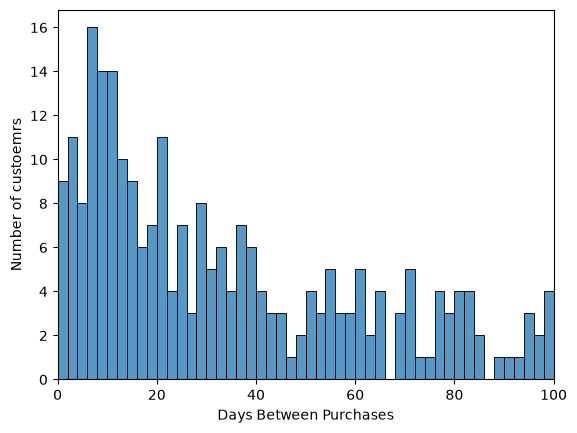

In [30]:
# Describe the column feature in a graph using seaborn


# Zoom x-axis to 0-100 and set y-axis to log scale
sb.histplot(x=cph_copy_filtered["avg_days_to_re_purchase"], binrange=(0, 100), bins=50)
plt.xlim(0, 100)
plt.xlabel("Days Between Purchases")
plt.ylabel("Number of custoemrs")
plt.show()


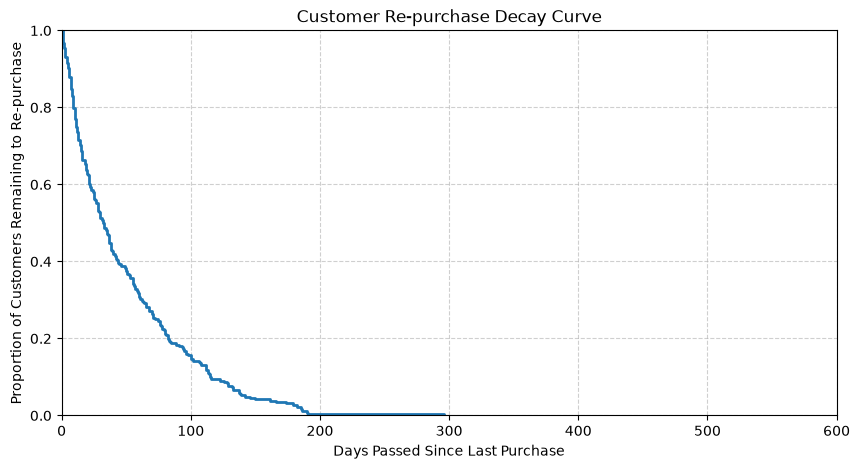

In [31]:
plt.figure(figsize=(10, 5))

# complementary=True flips the line to slope downwards from 1.0 to 0.0
sb.ecdfplot(data=cph_copy_filtered, x="avg_days_to_re_purchase", complementary=True, lw=2)

# Set x-axis limit (expanded to 180 days to see where it flattens near the bottom)
plt.xlim(0, 600)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Days Passed Since Last Purchase")
plt.ylabel("Proportion of Customers Remaining to Re-purchase")
plt.title("Customer Re-purchase Decay Curve")
plt.show()

Between 90, 100, 110 days

## Churn column with 90 days (max 1/07/2017)

churn columns from 2016-09-04

In [32]:
CHURN_DAYS = 90

In [33]:
start_date_90 = pd.to_datetime("2017-01-01")

start_date_90

Timestamp('2017-01-01 00:00:00')

In [34]:
ninety_days_later = start_date_90 + pd.Timedelta(days= CHURN_DAYS)

ninety_days_later

Timestamp('2017-04-01 00:00:00')

In [35]:
# Suming 90 days more to the variable ninety days later

end_date = ninety_days_later + pd.Timedelta(days= CHURN_DAYS)

end_date

Timestamp('2017-06-30 00:00:00')

In [36]:
max_date = olist_df["order_purchase_timestamp"].max()

max_date

Timestamp('2018-10-17 17:30:18')

In [37]:
limit_test = max_date - (pd.Timedelta(days= 110)*2)

test_period = limit_test - pd.Timedelta(days= 10)

test_period

Timestamp('2018-03-01 17:30:18')

In [38]:
max_date_onex2_ten = max_date - pd.Timedelta(days= 110)

max_date_onex2_ten

Timestamp('2018-06-29 17:30:18')

In [39]:
# Make a dataframe for the total 180 days of observation:
# 90 days to determine customers, and the other to observe if they have churned of not

obs_90_df = olist_df[(olist_df["order_purchase_timestamp"]>= start_date_90) & (olist_df["order_purchase_timestamp"] < end_date)]

obs_90_df



,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,purchase_date
48987,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,b33ec3b699337181488304f362a6b734,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,...,3.0,1500.0,25.0,50.0,35.0,13232.0,campo limpo paulista,SP,stationery,2017-03-10
70344,3b37fb626fdf46cd99d37ec62afa88ff,0005e1862207bf6ccc02e4228effd9a0,25966,teresopolis,RJ,ae76bef74b97bcb0b3e355e60d9a6f9c,delivered,2017-03-04 23:32:12,2017-03-04 23:43:26,2017-03-06 05:14:07,...,6.0,2250.0,22.0,15.0,20.0,37410.0,tres coracoes,MG,fashion_bags_accessories,2017-03-04
45642,064064dd94c43013786fc1e1a14d6374,00115fc7123b5310cf6d3a3aa932699e,71015,brasilia,DF,91d1bf2b7745903cb0d17162d1bbd750,delivered,2017-01-21 21:58:35,2017-01-21 22:10:13,2017-01-23 14:48:48,...,6.0,525.0,29.0,16.0,20.0,13456.0,santa barbara d'oeste,SP,sports_leisure,2017-01-21
38131,728e136fca2819b62d610743ae2904b8,0011805441c0d1b68b48002f1d005526,68639,goianesia do para,PA,fb5d8b462dc9570527eff204b8a1a57b,delivered,2017-04-24 13:36:48,2017-04-24 13:50:18,2017-04-27 12:35:22,...,1.0,200.0,18.0,8.0,16.0,5537.0,sao paulo,SP,computers_accessories,2017-04-24
18270,b821d548247d9c319bd595260efe677e,0011857aff0e5871ce5eb429f21cdaf5,9070,santo andre,SP,58d34816de3da57e9e07d7b34aced1b8,delivered,2017-06-28 11:08:38,2017-06-28 11:15:24,2017-06-30 10:18:13,...,2.0,483.0,24.0,25.0,29.0,74930.0,aparecida de goiania,GO,luggage_accessories,2017-06-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38753,a90468e2c3a73422673411b52aaa8426,ffef0ffa736c7b3d9af741611089729b,29830,nova venecia,ES,c8126206d94637a4e63af00f4181a14d,delivered,2017-05-29 22:07:05,2017-05-29 22:22:33,2017-05-31 12:04:00,...,1.0,1136.0,26.0,29.0,21.0,80610.0,curitiba,PR,sports_leisure,2017-05-29
106897,74be082247cd677a147d83ee670e9d53,fffcf5a5ff07b0908bd4e2dbc735a684,55250,sanharo,PE,725cf8e9c24e679a8a5a32cb92c9ce1e,delivered,2017-06-08 21:00:36,2017-06-08 21:15:16,2017-06-23 13:03:27,...,1.0,30000.0,55.0,75.0,61.0,3908.0,sao paulo,SP,health_beauty,2017-06-08
106898,74be082247cd677a147d83ee670e9d53,fffcf5a5ff07b0908bd4e2dbc735a684,55250,sanharo,PE,725cf8e9c24e679a8a5a32cb92c9ce1e,delivered,2017-06-08 21:00:36,2017-06-08 21:15:16,2017-06-23 13:03:27,...,1.0,30000.0,55.0,75.0,61.0,3908.0,sao paulo,SP,health_beauty,2017-06-08
82683,27f584b0f1dc4e610065c240f68b6be0,ffff371b4d645b6ecea244b27531430a,78552,sinop,MT,fdc45e6c7555e6cb3cc0daca2557dbe1,delivered,2017-02-07 15:49:16,2017-02-07 16:02:44,2017-02-08 10:04:37,...,5.0,600.0,17.0,15.0,13.0,30550.0,belo horizonte,MG,auto,2017-02-07


In [40]:
obs_90_df["is_customer"] = (
    (obs_90_df["order_purchase_timestamp"] >= start_date_90) & 
    (obs_90_df["order_purchase_timestamp"] < ninety_days_later)
).astype(int)

obs_90_df["is_customer"].value_counts()

is_customer
0    11113
1     6401
Name: count, dtype: int64

In [41]:
future_active_ids = obs_90_df[
    (obs_90_df["order_purchase_timestamp"] >= ninety_days_later) & 
    (obs_90_df["order_purchase_timestamp"] < end_date)
]["customer_unique_id"].unique()

future_active_ids

<StringArray>
['0011805441c0d1b68b48002f1d005526', '0011857aff0e5871ce5eb429f21cdaf5',
 '00191a9719ef48ebb5860b130347bf33', '001a2bf0e46c684031af91fb2bce149d',
 '002d71b244beb91ca7030b15ab526446', '00324c9f4d710e7bac5c5ba679714430',
 '0036a074f98b80c4f1fc33dbbcf9c552', '0043d65f8039b4a4d43bc7b0f450ac2c',
 '00444f48f6c9b55657e49435ce3a97ca', '0049dadc30da6a277c1e9d371df5a66f',
 ...
 'ffbb8dfaa0e54649d8690b85a3ef890d', 'ffbf790cac0b6cf2e411d9f158c0fbe2',
 'ffd44de1326179fff550dae07c6884c2', 'ffe254cc039740e17dd15a5305035928',
 'ffe4c3aa14d4702fb11fe5b3c4dd755c', 'ffe7752edcf14b5819058b1948e02f3a',
 'ffe9102bb78a76921ba0ff3c4659616a', 'ffef0ffa736c7b3d9af741611089729b',
 'fffcf5a5ff07b0908bd4e2dbc735a684', 'ffffd2657e2aad2907e67c3e9daecbeb']
Length: 9044, dtype: str

In [42]:
obs_90_df["churn_90"] = (
    (obs_90_df["is_customer"] == 1) & 
    (~obs_90_df["customer_unique_id"].isin(future_active_ids))
).astype(int)

obs_90_df["churn_90"]

48987     1
70344     1
45642     1
38131     0
18270     0
         ..
38753     0
106897    0
106898    0
82683     1
100279    0
Name: churn_90, Length: 17514, dtype: int64

In [43]:
print(obs_90_df["churn_90"].value_counts())

churn_90
0    11179
1     6335
Name: count, dtype: int64


In [44]:
dataset_90_df = obs_90_df.groupby(['customer_unique_id', 'order_purchase_timestamp', 'customer_city', 'customer_state', 'order_status']).agg({
    'price': 'sum',            # Total spent on the order (47.40 + 39.90)
    'freight_value': 'sum',    # Total shipping cost
    'payment_value': 'sum',    # Total amount charged to credit card
    'product_weight_g': 'sum', # Combined weight of the package


    # Categorical and indicator columns to pull forward
    'product_category_name_english': 'first',
    'is_customer': 'first',
    'churn_90': 'max',          # Keeps 1 if they churned, 0 otherwise
    'payment_sequential': 'max',
    'payment_type': 'first',
    'payment_installments': 'max'
}).reset_index()

dataset_90_df

,customer_unique_id,order_purchase_timestamp,customer_city,customer_state,order_status,price,freight_value,payment_value,product_weight_g,product_category_name_english,is_customer,churn_90,payment_sequential,payment_type,payment_installments
0,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,sao jose,SC,delivered,69.00,17.22,86.22,1500.0,stationery,1,1,1.0,credit_card,8.0
1,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,teresopolis,RJ,delivered,135.00,15.12,150.12,2250.0,fashion_bags_accessories,1,1,1.0,credit_card,3.0
2,00115fc7123b5310cf6d3a3aa932699e,2017-01-21 21:58:35,brasilia,DF,delivered,59.99,16.12,76.11,525.0,sports_leisure,1,1,1.0,credit_card,1.0
3,0011805441c0d1b68b48002f1d005526,2017-04-24 13:36:48,goianesia do para,PA,delivered,269.00,28.14,297.14,200.0,computers_accessories,0,0,1.0,credit_card,10.0
4,0011857aff0e5871ce5eb429f21cdaf5,2017-06-28 11:08:38,santo andre,SP,delivered,174.33,18.50,192.83,483.0,luggage_accessories,0,0,1.0,credit_card,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14466,ffedff0547d809c90c05c2691c51f9b7,2017-03-30 14:50:26,ribeirao preto,SP,delivered,17.90,14.52,32.42,225.0,housewares,1,1,1.0,credit_card,3.0
14467,ffef0ffa736c7b3d9af741611089729b,2017-05-29 22:07:05,nova venecia,ES,delivered,109.90,29.17,139.07,1136.0,sports_leisure,0,0,1.0,credit_card,1.0
14468,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36,sanharo,PE,delivered,1570.00,497.42,4134.84,60000.0,health_beauty,0,0,1.0,credit_card,10.0
14469,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16,sinop,MT,delivered,89.90,22.56,112.46,600.0,auto,1,1,1.0,credit_card,1.0


In [45]:
dataset_90_df["is_customer"].value_counts()

is_customer
0    9224
1    5247
Name: count, dtype: int64

In [46]:
dataset_90_df.to_csv(r"C:\Users\Hallen\Documents\mis_cosas\silvana\master\tfm-uned-churn\Data\churn_dataset_90.csv", index=False)

## Test Churn dataset with 90 days term (max 1/07/2017)

In [47]:
CHURN_DAYS = 90

In [48]:
start_date_90T = test_period

start_date_90T

Timestamp('2018-03-01 17:30:18')

In [49]:
ninety_days_laterT = start_date_90T + pd.Timedelta(days= CHURN_DAYS)

ninety_days_laterT

Timestamp('2018-05-30 17:30:18')

In [50]:
end_dateT = ninety_days_laterT + pd.Timedelta(days= CHURN_DAYS)

end_dateT

Timestamp('2018-08-28 17:30:18')

In [51]:
obs_90_test_df = olist_df[(olist_df["order_purchase_timestamp"]>= start_date_90T) & (olist_df["order_purchase_timestamp"] < end_dateT)]

obs_90_test_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,purchase_date
76714,fadbb3709178fc513abc1b2670aa1ad2,0000366f3b9a7992bf8c76cfdf3221e2,7787,cajamar,SP,e22acc9c116caa3f2b7121bbb380d08e,delivered,2018-05-10 10:56:27,2018-05-10 11:11:18,2018-05-12 08:18:00,...,1.0,1500.0,34.0,7.0,32.0,13405.0,piracicaba,SP,bed_bath_table,2018-05-10
29466,4cb282e167ae9234755102258dd52ee8,0000b849f77a49e4a4ce2b2a4ca5be3f,6053,osasco,SP,3594e05a005ac4d06a72673270ef9ec9,delivered,2018-05-07 11:11:27,2018-05-07 18:25:44,2018-05-09 12:18:00,...,1.0,375.0,26.0,11.0,18.0,2215.0,sao paulo,SP,health_beauty,2018-05-07
13347,4a913a170c26e3c8052ed0202849b5a8,0004bd2a26a76fe21f786e4fbd80607f,5036,sao paulo,SP,3e470077b690ea3e3d501cffb5e0c499,delivered,2018-04-05 19:33:16,2018-04-05 19:48:59,2018-04-07 00:38:52,...,3.0,3000.0,67.0,3.0,41.0,9171.0,santo andre,SP,garden_tools,2018-04-05
35389,d2509c13692836fc0449e88cf9eb4858,00050ab1314c0e55a6ca13cf7181fecf,13084,campinas,SP,d0028facea13f508e880202d7097a5a1,delivered,2018-04-20 12:57:23,2018-04-25 03:51:13,2018-04-25 15:25:00,...,6.0,300.0,17.0,4.0,12.0,4160.0,sao paulo,SP,telephony,2018-04-20
14384,c59e8ff99836e90d8b457d4122dc34e9,0005ef4cd20d2893f0d9fbd94d3c0d97,65060,sao luis,MA,01b330808c5819a6a3cb79b72f0b8288,delivered,2018-03-12 15:22:12,2018-03-12 15:38:46,2018-03-13 16:07:27,...,1.0,1136.0,26.0,29.0,21.0,25561.0,sao joao de meriti,RJ,sports_leisure,2018-03-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60570,ed583a2a1eaf0dedc33af816153e8b8c,fff5eb4918b2bf4b2da476788d42051c,58407,campina grande,PB,cf4659487be50c0c317cff3564c4a840,delivered,2018-07-02 16:39:59,2018-07-05 16:04:19,2018-07-06 08:25:00,...,3.0,18700.0,36.0,105.0,36.0,7113.0,guarulhos,SP,signaling_and_security,2018-07-02
60571,ed583a2a1eaf0dedc33af816153e8b8c,fff5eb4918b2bf4b2da476788d42051c,58407,campina grande,PB,cf4659487be50c0c317cff3564c4a840,delivered,2018-07-02 16:39:59,2018-07-05 16:04:19,2018-07-06 08:25:00,...,3.0,18700.0,36.0,105.0,36.0,7113.0,guarulhos,SP,signaling_and_security,2018-07-02
4568,cb2db09134b625c16f34f9240653c8b6,fff96bc586f78b1f070da28c4977e810,13309,itu,SP,991b6f0cb448175a229309dd55699710,delivered,2018-08-15 10:26:57,2018-08-15 10:44:06,2018-08-16 15:00:00,...,2.0,200.0,23.0,7.0,15.0,80510.0,curitiba,PR,housewares,2018-08-15
9943,a1746e37af49aa5afd6b195baed286eb,fffcc512b7dfecaffd80f13614af1d16,28909,cabo frio,RJ,158986977fa0c5043a8200b6b4563979,shipped,2018-04-11 00:34:32,2018-04-11 00:50:44,2018-04-11 20:41:54,...,2.0,867.0,20.0,7.0,14.0,14840.0,guariba,SP,watches_gifts,2018-04-11


In [52]:
obs_90_test_df["is_customer"] = (
    (obs_90_test_df["order_purchase_timestamp"] >= start_date_90T) & 
    (obs_90_test_df["order_purchase_timestamp"] < ninety_days_laterT)
).astype(int)

obs_90_test_df["is_customer"]

76714     1
29466     1
13347     1
35389     1
14384     1
         ..
60570     0
60571     0
4568      0
9943      1
113762    1
Name: is_customer, Length: 47186, dtype: int64

In [53]:
future_active_idsT = obs_90_test_df[
    (obs_90_test_df["order_purchase_timestamp"] >= ninety_days_laterT) & 
    (obs_90_test_df["order_purchase_timestamp"] < end_dateT)
]["customer_unique_id"].unique()

future_active_idsT

<StringArray>
['000e309254ab1fc5ba99dd469d36bdb4', '000ec5bff359e1c0ad76a81a45cb598f',
 '000fbf0473c10fc1ab6f8d2d286ce20c', '0015752e079902b12cd00b9b7596276b',
 '00172711b30d52eea8b313a7f2cced02', '001928b561575b2821c92254a2327d06',
 '00196c4c9a3af7dd2ad10eade69c926f', '001a34eb30ecb8e3aacb07c475ca4dd1',
 '001deb796b28a3a128d6113857569aa4', '002311514717ca8b65b09a26cdf7b91a',
 ...
 'ffe6305176b9431a3eda3cf8904d7eb7', 'ffe96201d466b0e0dc8139850be29d5d',
 'ffe96c782a5bc522bd8bad3bc638981a', 'ffeb904468642a1ce663a322629801cb',
 'ffec490ab531184a483efe2eedd68908', 'ffee94d548cef05b146d825a7648dab4',
 'fff22793223fe80c97a8fd02ac5c6295', 'fff3e1d7bc75f11dc7670619b2e61840',
 'fff5eb4918b2bf4b2da476788d42051c', 'fff96bc586f78b1f070da28c4977e810']
Length: 18876, dtype: str

In [54]:
obs_90_test_df["churn_90"] = (
    (obs_90_test_df["is_customer"] == 1) & 
    (~obs_90_test_df["customer_unique_id"].isin(future_active_idsT))
).astype(int)

obs_90_test_df["churn_90"]

76714     1
29466     1
13347     1
35389     1
14384     1
         ..
60570     0
60571     0
4568      0
9943      1
113762    1
Name: churn_90, Length: 47186, dtype: int64

In [55]:
obs_90_test_df = obs_90_test_df.groupby(['customer_unique_id', 'order_purchase_timestamp', 'customer_city', 'customer_state', 'order_status']).agg({
    'price': 'sum',            # Total spent on the order (47.40 + 39.90)
    'freight_value': 'sum',    # Total shipping cost
    'payment_value': 'sum',    # Total amount charged to credit card
    'product_weight_g': 'sum', # Combined weight of the package


    # Categorical and indicator columns to pull forward
    'product_category_name_english': 'first',
    'is_customer': 'first',
    'churn_90': 'max',          # Keeps 1 if they churned, 0 otherwise
    'payment_sequential': 'max',
    'payment_type': 'first',
    'payment_installments': 'max'
}).reset_index()

obs_90_test_df

,customer_unique_id,order_purchase_timestamp,customer_city,customer_state,order_status,price,freight_value,payment_value,product_weight_g,product_category_name_english,is_customer,churn_90,payment_sequential,payment_type,payment_installments
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,cajamar,SP,delivered,129.90,12.00,141.90,1500.0,bed_bath_table,1,1,1.0,credit_card,8.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,osasco,SP,delivered,18.90,8.29,27.19,375.0,health_beauty,1,1,1.0,credit_card,1.0
2,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,sao paulo,SP,delivered,154.00,12.98,166.98,3000.0,garden_tools,1,1,1.0,credit_card,8.0
3,00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,campinas,SP,delivered,27.99,7.39,35.38,300.0,telephony,1,1,1.0,boleto,1.0
4,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-12 15:22:12,sao luis,MA,delivered,104.90,24.86,129.76,1136.0,sports_leisure,1,1,1.0,credit_card,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39692,fff3e1d7bc75f11dc7670619b2e61840,2018-07-20 13:47:30,teresina,PI,delivered,54.85,27.66,82.51,100.0,computers_accessories,0,0,1.0,debit_card,1.0
39693,fff5eb4918b2bf4b2da476788d42051c,2018-07-02 16:39:59,campina grande,PB,delivered,1050.00,1794.96,17069.76,112200.0,signaling_and_security,0,0,1.0,boleto,1.0
39694,fff96bc586f78b1f070da28c4977e810,2018-08-15 10:26:57,itu,SP,delivered,45.00,18.42,63.42,200.0,housewares,0,0,1.0,credit_card,2.0
39695,fffcc512b7dfecaffd80f13614af1d16,2018-04-11 00:34:32,cabo frio,RJ,shipped,688.00,22.70,710.70,867.0,watches_gifts,1,1,1.0,credit_card,3.0


In [56]:
obs_90_test_df.to_csv(r"C:\Users\Hallen\Documents\mis_cosas\silvana\master\tfm-uned-churn\Data\churn_test_90_dataset.csv", index=False)

## Churn column with 90 days term 2(max 1/07/2017)

In [85]:
term_2_90_start = end_date

term_2_90_start

Timestamp('2017-03-03 21:15:19')

In [86]:
term_2_90_plus = end_date + pd.Timedelta(days= CHURN_DAYS)

term_2_90_plus

Timestamp('2017-06-01 21:15:19')

In [88]:
term_2_end = term_2_90_plus + pd.Timedelta(days= CHURN_DAYS)

term_2_end

Timestamp('2017-08-30 21:15:19')

In [89]:
obs_t2_90_df = olist_df[(olist_df["order_purchase_timestamp"]>= term_2_90_start) & (olist_df["order_purchase_timestamp"] < term_2_end)]

obs_t2_90_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,purchase_date
48987,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,b33ec3b699337181488304f362a6b734,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,...,3.0,1500.0,25.0,50.0,35.0,13232.0,campo limpo paulista,SP,stationery,2017-03-10
70344,3b37fb626fdf46cd99d37ec62afa88ff,0005e1862207bf6ccc02e4228effd9a0,25966,teresopolis,RJ,ae76bef74b97bcb0b3e355e60d9a6f9c,delivered,2017-03-04 23:32:12,2017-03-04 23:43:26,2017-03-06 05:14:07,...,6.0,2250.0,22.0,15.0,20.0,37410.0,tres coracoes,MG,fashion_bags_accessories,2017-03-04
76075,2f29573c8cac5a7be11c5b649078f944,0006fdc98a402fceb4eb0ee528f6a8d4,29400,mimoso do sul,ES,6681163e3dab91c549952b2845b20281,delivered,2017-07-18 09:23:10,2017-07-18 09:30:22,2017-07-21 16:13:08,...,1.0,200.0,30.0,4.0,40.0,14940.0,ibitinga,SP,bed_bath_table,2017-07-18
8305,be22f11baf346059cbe6556ef9c69070,000a5ad9c4601d2bbdd9ed765d5213b3,90560,porto alegre,RS,f7fa5cf8386e51037856df1add3e1228,delivered,2017-08-11 13:45:15,2017-08-11 14:04:05,2017-08-14 12:30:08,...,3.0,600.0,17.0,22.0,20.0,4403.0,sao paulo,SP,health_beauty,2017-08-11
14079,455f2e2988eaf87d7e2ba33b0a57969f,000de6019bb59f34c099a907c151d855,11612,sao sebastiao,SP,c6d61340bd8baeedca7cc8e7f7ec07e9,delivered,2017-08-17 19:10:33,2017-08-17 19:55:22,2017-08-18 14:13:07,...,1.0,1200.0,44.0,2.0,35.0,13405.0,piracicaba,SP,bed_bath_table,2017-08-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38753,a90468e2c3a73422673411b52aaa8426,ffef0ffa736c7b3d9af741611089729b,29830,nova venecia,ES,c8126206d94637a4e63af00f4181a14d,delivered,2017-05-29 22:07:05,2017-05-29 22:22:33,2017-05-31 12:04:00,...,1.0,1136.0,26.0,29.0,21.0,80610.0,curitiba,PR,sports_leisure,2017-05-29
68949,c445b065520c54b05cc0f634e502da29,fff3a9369e4b7102fab406a334a678c3,70067,brasilia,DF,1f9e91cd0451c86ff49e428f06111021,delivered,2017-08-11 10:26:38,2017-08-11 10:44:45,2017-08-11 18:31:58,...,1.0,1450.0,49.0,10.0,33.0,37564.0,borda da mata,MG,luggage_accessories,2017-08-11
106897,74be082247cd677a147d83ee670e9d53,fffcf5a5ff07b0908bd4e2dbc735a684,55250,sanharo,PE,725cf8e9c24e679a8a5a32cb92c9ce1e,delivered,2017-06-08 21:00:36,2017-06-08 21:15:16,2017-06-23 13:03:27,...,1.0,30000.0,55.0,75.0,61.0,3908.0,sao paulo,SP,health_beauty,2017-06-08
106898,74be082247cd677a147d83ee670e9d53,fffcf5a5ff07b0908bd4e2dbc735a684,55250,sanharo,PE,725cf8e9c24e679a8a5a32cb92c9ce1e,delivered,2017-06-08 21:00:36,2017-06-08 21:15:16,2017-06-23 13:03:27,...,1.0,30000.0,55.0,75.0,61.0,3908.0,sao paulo,SP,health_beauty,2017-06-08


In [ ]:
#obs_t2_90_df["is_customer"] = (
#    (obs_t2_90_df["order_purchase_timestamp"] >= term_2_90_start) & 
#    (obs_t2_90_df["order_purchase_timestamp"] < term_2_90_plus)
#).astype(int)

##obs_t2_90_df["is_customer"]

## Churn column with 100 days (max 1/07/2017)

In [44]:
CHURN_DAYS = 100

In [45]:
start_date_100 = olist_df["order_purchase_timestamp"].min()

start_date_100

Timestamp('2016-09-04 21:15:19')

In [49]:
one_hundred_days_later = start_date_100 + pd.Timedelta(days= CHURN_DAYS)

one_hundred_days_later

Timestamp('2016-12-13 21:15:19')

In [50]:
end_date = one_hundred_days_later + pd.Timedelta(days= CHURN_DAYS)

end_date

Timestamp('2017-03-23 21:15:19')

In [51]:
obs_100_df = olist_df[(olist_df["order_purchase_timestamp"]>= start_date_100) & (olist_df["order_purchase_timestamp"] < end_date)]

obs_100_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,purchase_date
48987,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,b33ec3b699337181488304f362a6b734,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,...,3.0,1500.0,25.0,50.0,35.0,13232.0,campo limpo paulista,SP,stationery,2017-03-10
70344,3b37fb626fdf46cd99d37ec62afa88ff,0005e1862207bf6ccc02e4228effd9a0,25966,teresopolis,RJ,ae76bef74b97bcb0b3e355e60d9a6f9c,delivered,2017-03-04 23:32:12,2017-03-04 23:43:26,2017-03-06 05:14:07,...,6.0,2250.0,22.0,15.0,20.0,37410.0,tres coracoes,MG,fashion_bags_accessories,2017-03-04
45642,064064dd94c43013786fc1e1a14d6374,00115fc7123b5310cf6d3a3aa932699e,71015,brasilia,DF,91d1bf2b7745903cb0d17162d1bbd750,delivered,2017-01-21 21:58:35,2017-01-21 22:10:13,2017-01-23 14:48:48,...,6.0,525.0,29.0,16.0,20.0,13456.0,santa barbara d'oeste,SP,sports_leisure,2017-01-21
28204,c267e32fea07ffc4d9d388d44c4106c7,001f3c4211216384d5fe59b041ce1461,8240,sao paulo,SP,7845d9a1a3d511b756a5c2c2352ba770,delivered,2017-03-19 18:34:36,2017-03-19 18:34:36,2017-03-21 17:28:28,...,1.0,250.0,16.0,2.0,11.0,12243.0,sao jose dos campos,SP,housewares,2017-03-19
63018,9d4b49b0fc9981a6ad9b314e6ce43925,002b4cd83fabaffaa475f78ea5ef3e08,37950,sao sebastiao do paraiso,MG,22bf3dde4d90667a74118fad0041bfd5,delivered,2017-02-01 13:53:16,2017-02-01 14:05:16,2017-02-02 14:26:38,...,5.0,150.0,16.0,5.0,20.0,2252.0,sao paulo,SP,fashion_bags_accessories,2017-02-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47661,c4c271a679216c43812602c08b2104cd,ffba9f9dff87b05e310ecc46c8591044,68695,tailandia,PA,201f31fb8c21cbe559ac45d1de5f4392,delivered,2017-02-27 15:39:41,2017-02-27 15:50:17,2017-03-01 11:06:01,...,3.0,500.0,23.0,15.0,19.0,6429.0,barueri,SP,watches_gifts,2017-02-27
48972,97a2b94eabebd1d79f9ba6ace3ae5757,ffe2dd1f3b0cbf0b5f35e818ec03c49b,22770,rio de janeiro,RJ,c224a880841d56f37bdae6fe71fb8540,delivered,2017-03-05 21:23:38,2017-03-05 21:35:10,2017-03-06 13:42:33,...,1.0,1750.0,30.0,20.0,25.0,14940.0,ibitinga,SP,bed_bath_table,2017-03-05
110069,e85ff8cc3cc2c09bdb9204dd7930c0fb,ffe3e199b9d0b7fb7d2d29a5b9498447,38411,uberlandia,MG,ffea406a848c8afe4dec22bf6290ba00,delivered,2017-03-15 17:16:36,2017-03-15 17:16:36,2017-03-16 12:54:46,...,2.0,350.0,18.0,15.0,16.0,13403.0,piracicaba,SP,home_construction,2017-03-15
26818,3619684d733b95a9860ca496206a6ab0,ffebb6424578e7bb153322da9d65634f,7260,guarulhos,SP,d3a49dd2f9c21558b7a82c8f076f6c1d,delivered,2017-01-16 14:04:11,2017-01-18 14:01:22,2017-02-10 07:07:43,...,2.0,7100.0,36.0,47.0,32.0,94910.0,cachoeirinha,RS,cool_stuff,2017-01-16


In [54]:
obs_100_df["is_customer"] = (
    (obs_100_df["order_purchase_timestamp"] >= start_date_100) & 
    (obs_100_df["order_purchase_timestamp"] < one_hundred_days_later)
).astype(int)

obs_100_df["is_customer"]

48987     0
70344     0
45642     0
28204     0
63018     0
         ..
47661     0
48972     0
110069    0
26818     0
82683     0
Name: is_customer, Length: 6027, dtype: int64

In [57]:
future_active_ids = obs_100_df[
    (obs_100_df["order_purchase_timestamp"] >= one_hundred_days_later) & 
    (obs_100_df["order_purchase_timestamp"] < end_date)
]["customer_unique_id"].unique()

future_active_ids

<StringArray>
['0000f46a3911fa3c0805444483337064', '0005e1862207bf6ccc02e4228effd9a0',
 '00115fc7123b5310cf6d3a3aa932699e', '001f3c4211216384d5fe59b041ce1461',
 '002b4cd83fabaffaa475f78ea5ef3e08', '003e28cb6fab8a0901bff9229612375f',
 '00446a03d7a34d191507c9e42870d0a5', '0049db44bfd6cee26ac9c649329ff6ea',
 '0055b522bc89cbfbf376d8b59a628470', '0071f46a072a9ae25bbe4438b15efe9c',
 ...
 'ff9bc66daa6702543b16f3c4897e300b', 'ffa0ba4c9a6a0763879efe7c2b8d5b93',
 'ffa17ff63f95ea3c838670e61d2666e0', 'ffa46fd1f769dfbdd6c039550b420949',
 'ffafb9f09293653c2486abe52e5e05a4', 'ffba9f9dff87b05e310ecc46c8591044',
 'ffe2dd1f3b0cbf0b5f35e818ec03c49b', 'ffe3e199b9d0b7fb7d2d29a5b9498447',
 'ffebb6424578e7bb153322da9d65634f', 'ffff371b4d645b6ecea244b27531430a']
Length: 4489, dtype: str

In [ ]:
obs_100_df["churn_100"] = (
    (obs_100_df["is_customer"] == 1) & 
    (~obs_100_df["customer_unique_id"].isin(future_active_ids))
).astype(int)

obs_100_df["churn_100"]

48987     0
70344     0
45642     0
28204     0
63018     0
         ..
47661     0
48972     0
110069    0
26818     0
82683     0
Name: churn_100, Length: 6027, dtype: int64

In [59]:
dataset_100_df = obs_100_df.groupby(['customer_id', 'order_purchase_timestamp', 'customer_city', 'customer_state', 'order_status']).agg({
    'price': 'sum',            # Total spent on the order (47.40 + 39.90)
    'freight_value': 'sum',    # Total shipping cost
    'payment_value': 'sum',    # Total amount charged to credit card
    'product_weight_g': 'sum', # Combined weight of the package


    # Categorical and indicator columns to pull forward
    'product_category_name_english': 'first',
    'is_customer': 'first',
    'churn_100': 'max',          # Keeps 1 if they churned, 0 otherwise
    'payment_sequential': 'max',
    'payment_type': 'first',
    'payment_installments': 'max'
}).reset_index()

dataset_100_df

,customer_id,order_purchase_timestamp,customer_city,customer_state,order_status,price,freight_value,payment_value,product_weight_g,product_category_name_english,is_customer,churn_100,payment_sequential,payment_type,payment_installments
0,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,nova venecia,ES,delivered,179.99,15.43,195.42,750.0,baby,0,0,1.0,credit_card,10.0
1,00062b33cb9f6fe976afdcff967ea74d,2017-03-15 23:44:09,sao paulo,SP,delivered,47.99,10.96,58.95,250.0,health_beauty,0,0,1.0,boleto,1.0
2,001f6f1a5e902ad14e1f709a7215de11,2017-02-07 20:32:13,campos do jordao,SP,delivered,23.90,10.96,34.86,225.0,health_beauty,0,0,1.0,credit_card,1.0
3,0031c1062edf836ef7a7a7ea758b137b,2017-03-01 20:00:23,itaborai,RJ,delivered,69.90,11.10,81.00,2033.0,health_beauty,0,0,1.0,credit_card,2.0
4,0040b00970e2139e8c43b647c0da5305,2017-01-26 23:10:07,atibaia,SP,delivered,30.97,10.96,41.93,443.0,health_beauty,0,0,1.0,credit_card,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4909,ffc261b1c1e12a951ee0fc9d27463d3d,2017-02-21 16:17:51,francisco morato,SP,delivered,58.50,11.02,69.52,250.0,auto,0,0,1.0,credit_card,6.0
4910,ffcff7222f737ae6b440d4d0da1496d3,2017-03-07 17:35:28,sao paulo,SP,delivered,30.90,10.53,41.43,1300.0,garden_tools,0,0,1.0,boleto,1.0
4911,ffe51ba924ffabbb6e1ec2c92e582851,2017-01-20 22:11:31,sao paulo,SP,delivered,34.90,14.11,49.01,500.0,fashion_shoes,0,0,1.0,credit_card,4.0
4912,ffeac04ef924e20238b3ad2f9cecfbfa,2017-02-01 21:13:54,olimpia,SP,delivered,26.90,11.74,38.64,950.0,computers_accessories,0,0,1.0,credit_card,1.0


In [60]:
dataset_100_df.to_csv(r"C:\Users\Hallen\Documents\mis_cosas\silvana\master\tfm-uned-churn\Data\churn_100_dataset.csv", index=False)

## Churn column with 110 days (max 1/07/2017)

In [61]:
CHURN_DAYS = 110

In [62]:
start_date_110 = olist_df["order_purchase_timestamp"].min()

start_date_110

Timestamp('2016-09-04 21:15:19')

In [64]:
one_hundred_ten_days_later = start_date_110 + pd.Timedelta(days= CHURN_DAYS)

one_hundred_ten_days_later

Timestamp('2016-12-23 21:15:19')

In [66]:
end_date = one_hundred_ten_days_later + pd.Timedelta(days= CHURN_DAYS)

end_date

Timestamp('2017-04-12 21:15:19')

In [67]:
obs_110_df = olist_df[(olist_df["order_purchase_timestamp"]>= start_date_110) & (olist_df["order_purchase_timestamp"] < end_date)]

obs_110_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,purchase_date
48987,9b3932a6253894a02c1df9d19004239f,0000f46a3911fa3c0805444483337064,88115,sao jose,SC,b33ec3b699337181488304f362a6b734,delivered,2017-03-10 21:05:03,2017-03-10 21:05:03,2017-03-13 12:58:30,...,3.0,1500.0,25.0,50.0,35.0,13232.0,campo limpo paulista,SP,stationery,2017-03-10
70344,3b37fb626fdf46cd99d37ec62afa88ff,0005e1862207bf6ccc02e4228effd9a0,25966,teresopolis,RJ,ae76bef74b97bcb0b3e355e60d9a6f9c,delivered,2017-03-04 23:32:12,2017-03-04 23:43:26,2017-03-06 05:14:07,...,6.0,2250.0,22.0,15.0,20.0,37410.0,tres coracoes,MG,fashion_bags_accessories,2017-03-04
45642,064064dd94c43013786fc1e1a14d6374,00115fc7123b5310cf6d3a3aa932699e,71015,brasilia,DF,91d1bf2b7745903cb0d17162d1bbd750,delivered,2017-01-21 21:58:35,2017-01-21 22:10:13,2017-01-23 14:48:48,...,6.0,525.0,29.0,16.0,20.0,13456.0,santa barbara d'oeste,SP,sports_leisure,2017-01-21
28204,c267e32fea07ffc4d9d388d44c4106c7,001f3c4211216384d5fe59b041ce1461,8240,sao paulo,SP,7845d9a1a3d511b756a5c2c2352ba770,delivered,2017-03-19 18:34:36,2017-03-19 18:34:36,2017-03-21 17:28:28,...,1.0,250.0,16.0,2.0,11.0,12243.0,sao jose dos campos,SP,housewares,2017-03-19
117933,14e4fd056129b209f512b1070b405ccc,002043098f10ba39a4600b6c52fbfe3c,49015,aracaju,SE,4c5fb984844ad48dc34f8acf42eb0eda,delivered,2017-03-26 16:45:59,2017-03-26 17:02:14,2017-04-05 16:54:52,...,1.0,10725.0,57.0,55.0,22.0,8577.0,itaquaquecetuba,SP,office_furniture,2017-03-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48972,97a2b94eabebd1d79f9ba6ace3ae5757,ffe2dd1f3b0cbf0b5f35e818ec03c49b,22770,rio de janeiro,RJ,c224a880841d56f37bdae6fe71fb8540,delivered,2017-03-05 21:23:38,2017-03-05 21:35:10,2017-03-06 13:42:33,...,1.0,1750.0,30.0,20.0,25.0,14940.0,ibitinga,SP,bed_bath_table,2017-03-05
110069,e85ff8cc3cc2c09bdb9204dd7930c0fb,ffe3e199b9d0b7fb7d2d29a5b9498447,38411,uberlandia,MG,ffea406a848c8afe4dec22bf6290ba00,delivered,2017-03-15 17:16:36,2017-03-15 17:16:36,2017-03-16 12:54:46,...,2.0,350.0,18.0,15.0,16.0,13403.0,piracicaba,SP,home_construction,2017-03-15
26818,3619684d733b95a9860ca496206a6ab0,ffebb6424578e7bb153322da9d65634f,7260,guarulhos,SP,d3a49dd2f9c21558b7a82c8f076f6c1d,delivered,2017-01-16 14:04:11,2017-01-18 14:01:22,2017-02-10 07:07:43,...,2.0,7100.0,36.0,47.0,32.0,94910.0,cachoeirinha,RS,cool_stuff,2017-01-16
10977,9f9233b73bc4030c589a0429b3423766,ffedff0547d809c90c05c2691c51f9b7,14091,ribeirao preto,SP,fafb40d4bbf282fe7b9bbafcc2eef58a,delivered,2017-03-30 14:50:26,2017-03-30 15:05:18,2017-04-04 15:13:32,...,1.0,225.0,18.0,16.0,46.0,31255.0,belo horizonte,MG,housewares,2017-03-30


In [68]:
obs_110_df["is_customer"] = (
    (obs_110_df["order_purchase_timestamp"] >= start_date_110) & 
    (obs_110_df["order_purchase_timestamp"] < one_hundred_ten_days_later)
).astype(int)

obs_110_df["is_customer"]

48987     0
70344     0
45642     0
28204     0
117933    0
         ..
48972     0
110069    0
26818     0
10977     0
82683     0
Name: is_customer, Length: 7912, dtype: int64

In [71]:
future_active_ids = obs_110_df[
    (obs_110_df["order_purchase_timestamp"] >= one_hundred_ten_days_later) & 
    (obs_110_df["order_purchase_timestamp"] < end_date)
]["customer_unique_id"].unique()

future_active_ids

<StringArray>
['0000f46a3911fa3c0805444483337064', '0005e1862207bf6ccc02e4228effd9a0',
 '00115fc7123b5310cf6d3a3aa932699e', '001f3c4211216384d5fe59b041ce1461',
 '002043098f10ba39a4600b6c52fbfe3c', '002b4cd83fabaffaa475f78ea5ef3e08',
 '0037d2bbb9ebc39d9114aea27ee16d72', '003e28cb6fab8a0901bff9229612375f',
 '00446a03d7a34d191507c9e42870d0a5', '0049db44bfd6cee26ac9c649329ff6ea',
 ...
 'ffa17ff63f95ea3c838670e61d2666e0', 'ffa46fd1f769dfbdd6c039550b420949',
 'ffafb9f09293653c2486abe52e5e05a4', 'ffba9f9dff87b05e310ecc46c8591044',
 'ffe254cc039740e17dd15a5305035928', 'ffe2dd1f3b0cbf0b5f35e818ec03c49b',
 'ffe3e199b9d0b7fb7d2d29a5b9498447', 'ffebb6424578e7bb153322da9d65634f',
 'ffedff0547d809c90c05c2691c51f9b7', 'ffff371b4d645b6ecea244b27531430a']
Length: 6062, dtype: str

In [73]:
obs_110_df["churn_110"] = (
    (obs_110_df["is_customer"] == 1) & 
    (~obs_110_df["customer_unique_id"].isin(future_active_ids))
).astype(int)

obs_110_df["churn_110"]

48987     0
70344     0
45642     0
28204     0
117933    0
         ..
48972     0
110069    0
26818     0
10977     0
82683     0
Name: churn_110, Length: 7912, dtype: int64

In [75]:
dataset_110_df = obs_110_df.groupby(['customer_id', 'order_purchase_timestamp', 'customer_city', 'customer_state', 'order_status']).agg({
    'price': 'sum',            # Total spent on the order (47.40 + 39.90)
    'freight_value': 'sum',    # Total shipping cost
    'payment_value': 'sum',    # Total amount charged to credit card
    'product_weight_g': 'sum', # Combined weight of the package


    # Categorical and indicator columns to pull forward
    'product_category_name_english': 'first',
    'is_customer': 'first',
    'churn_110': 'max',          # Keeps 1 if they churned, 0 otherwise
    'payment_sequential': 'max',
    'payment_type': 'first',
    'payment_installments': 'max'
}).reset_index()

dataset_110_df

,customer_id,order_purchase_timestamp,customer_city,customer_state,order_status,price,freight_value,payment_value,product_weight_g,product_category_name_english,is_customer,churn_110,payment_sequential,payment_type,payment_installments
0,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,nova venecia,ES,delivered,179.99,15.43,195.42,750.0,baby,0,0,1.0,credit_card,10.0
1,0004164d20a9e969af783496f3408652,2017-04-12 08:35:12,valinhos,SP,delivered,59.99,11.81,71.80,800.0,sports_leisure,0,0,1.0,voucher,1.0
2,00062b33cb9f6fe976afdcff967ea74d,2017-03-15 23:44:09,sao paulo,SP,delivered,47.99,10.96,58.95,250.0,health_beauty,0,0,1.0,boleto,1.0
3,0010068a73b7c56da5758c3f9e5c7375,2017-04-11 18:19:55,parambu,CE,delivered,29.99,24.84,54.83,100.0,telephony,0,0,1.0,boleto,1.0
4,001f6f1a5e902ad14e1f709a7215de11,2017-02-07 20:32:13,campos do jordao,SP,delivered,23.90,10.96,34.86,225.0,health_beauty,0,0,1.0,credit_card,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6521,ffcff7222f737ae6b440d4d0da1496d3,2017-03-07 17:35:28,sao paulo,SP,delivered,30.90,10.53,41.43,1300.0,garden_tools,0,0,1.0,boleto,1.0
6522,ffe51ba924ffabbb6e1ec2c92e582851,2017-01-20 22:11:31,sao paulo,SP,delivered,34.90,14.11,49.01,500.0,fashion_shoes,0,0,1.0,credit_card,4.0
6523,ffeac04ef924e20238b3ad2f9cecfbfa,2017-02-01 21:13:54,olimpia,SP,delivered,26.90,11.74,38.64,950.0,computers_accessories,0,0,1.0,credit_card,1.0
6524,fff200ad56bd3e1caa576cce9d282672,2017-02-12 20:42:26,campo grande,MS,delivered,92.90,20.97,113.87,2650.0,agro_industry_and_commerce,0,0,1.0,credit_card,1.0


In [76]:
dataset_110_df.to_csv(r"C:\Users\Hallen\Documents\mis_cosas\silvana\master\tfm-uned-churn\Data\churn_110_dataset.csv", index=False)